In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv("spotify_data clean.csv")

In [18]:
def parse_genres(x):
    if pd.isna(x):
        return []
    return [g.strip() for g in str(x).split(",")]

df["artist_genres"] = df["artist_genres"].apply(parse_genres)

G = nx.Graph()

for _, row in df.iterrows():
    artist = row["artist_name"]
    genres = row["artist_genres"]

    for genre in genres:
        G.add_edge(artist, genre)

print("Graph statistics")
print("----------------")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))


Graph statistics
----------------
Nodes: 1642
Edges: 2302
Density: 0.0017086518499385048


In [19]:
artists = set(df["artist_name"])

degree_centrality = nx.degree_centrality(G)

artist_degree = {
    node: score
    for node, score in degree_centrality.items()
    if node in artists
}

top_degree = sorted(artist_degree.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 artists by degree centrality:")
for artist, score in top_degree:
    print(artist, score)


Top 10 artists by degree centrality:
Grupo Frontera 0.006093845216331505
Fuerza Regida 0.004875076173065204
Virtual Riot 0.004875076173065204
Oscar Maydon 0.0042656916514320535
Peso Pluma 0.0042656916514320535
Xavi 0.0042656916514320535
Wizkid 0.0042656916514320535
Boy Harsher 0.0042656916514320535
Brian Eno 0.0042656916514320535
PsychoYP 0.0036563071297989035


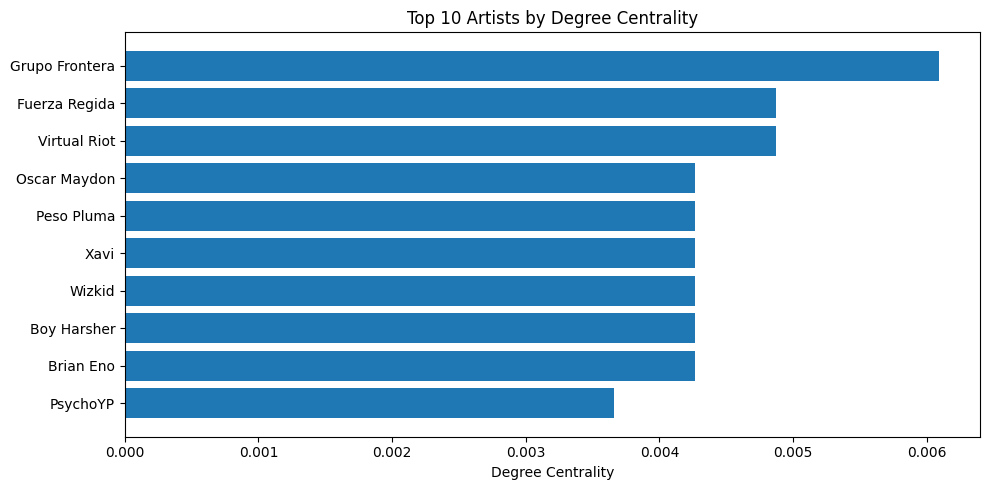

In [20]:
top_degree = sorted(artist_degree.items(), key=lambda x: x[1], reverse=True)[:10]

artists_deg = [x[0] for x in top_degree]
scores_deg = [x[1] for x in top_degree]

plt.figure(figsize=(10,5))
plt.barh(artists_deg, scores_deg)
plt.xlabel("Degree Centrality")
plt.title("Top 10 Artists by Degree Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
betweenness = nx.betweenness_centrality(G)

artist_betweenness = {
    node: score
    for node, score in betweenness.items()
    if node in artists
}

top_bridge = sorted(artist_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 artists by betweeness centrality:")
for artist, score in top_bridge:
    print(artist, score)


Top 10 artists by betweeness centrality:
Charli xcx 0.10970828739627529
Odetari 0.10708652326147408
Taylor Swift 0.09852717315891522
Post Malone 0.09728703929374637
Rihanna 0.061121194048319595
Kyle Dixon & Michael Stein 0.05869262175586356
Lady Gaga 0.057300890528108855
The Weeknd 0.05560755464802243
Vestron Vulture 0.051658738856334256
Lil Tjay 0.04631916885896464


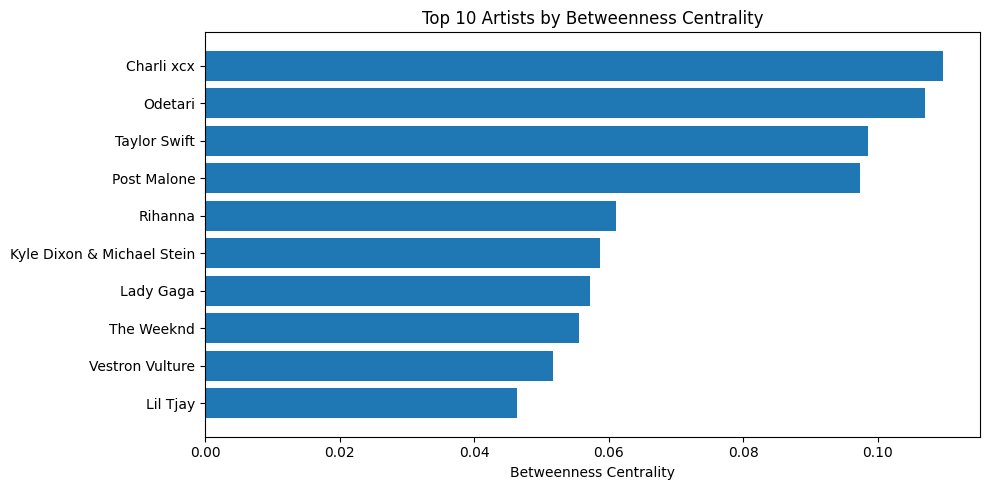

In [22]:
top_bridge = sorted(artist_betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

artists_bet = [x[0] for x in top_bridge]
scores_bet = [x[1] for x in top_bridge]

plt.figure(figsize=(10,5))
plt.barh(artists_bet, scores_bet)
plt.xlabel("Betweenness Centrality")
plt.title("Top 10 Artists by Betweenness Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
pagerank = nx.pagerank(G)

artist_pr = {node: score for node, score in pagerank.items() if node in artists}

top_pr = sorted(artist_pr.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 artists by Page Rank")
for artist, score in top_pr:
    print(artist, score)

Top 10 artists by Page Rank
Virtual Riot 0.0017844118733604877
Grupo Frontera 0.0015922399470433665
Brian Eno 0.0014003865844242557
Nina Simone 0.0013374732711123538
Kyuss 0.0012010534777253342
Wizkid 0.0011832962464148125
Raghav 0.0011721802501457358
Vanessa Da Mata 0.0011678065931050414
Cœur De Pirate 0.0011205790816234593
Spice 0.001096078342020332


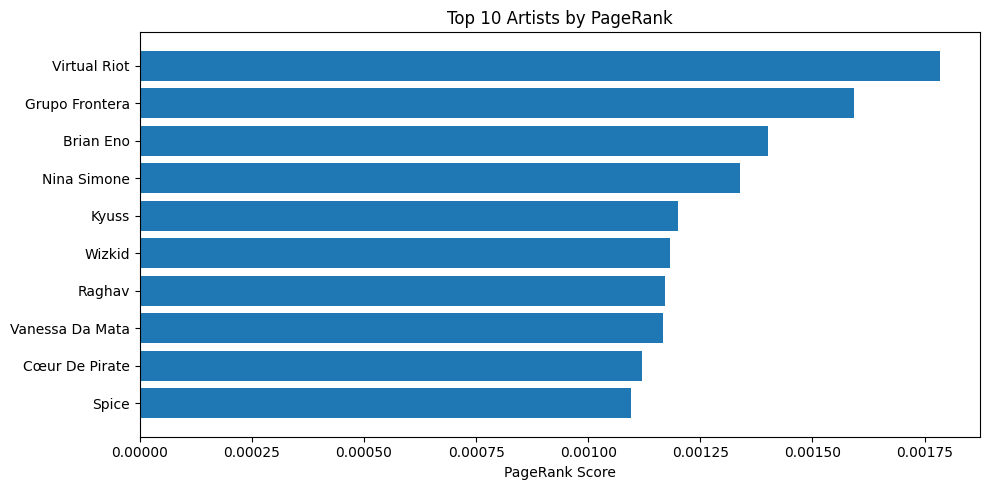

In [24]:
top_pr = sorted(artist_pr.items(), key=lambda x: x[1], reverse=True)[:10]

artists_pr = [x[0] for x in top_pr]
scores_pr = [x[1] for x in top_pr]

plt.figure(figsize=(10,5))
plt.barh(artists_pr, scores_pr)
plt.xlabel("PageRank Score")
plt.title("Top 10 Artists by PageRank")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

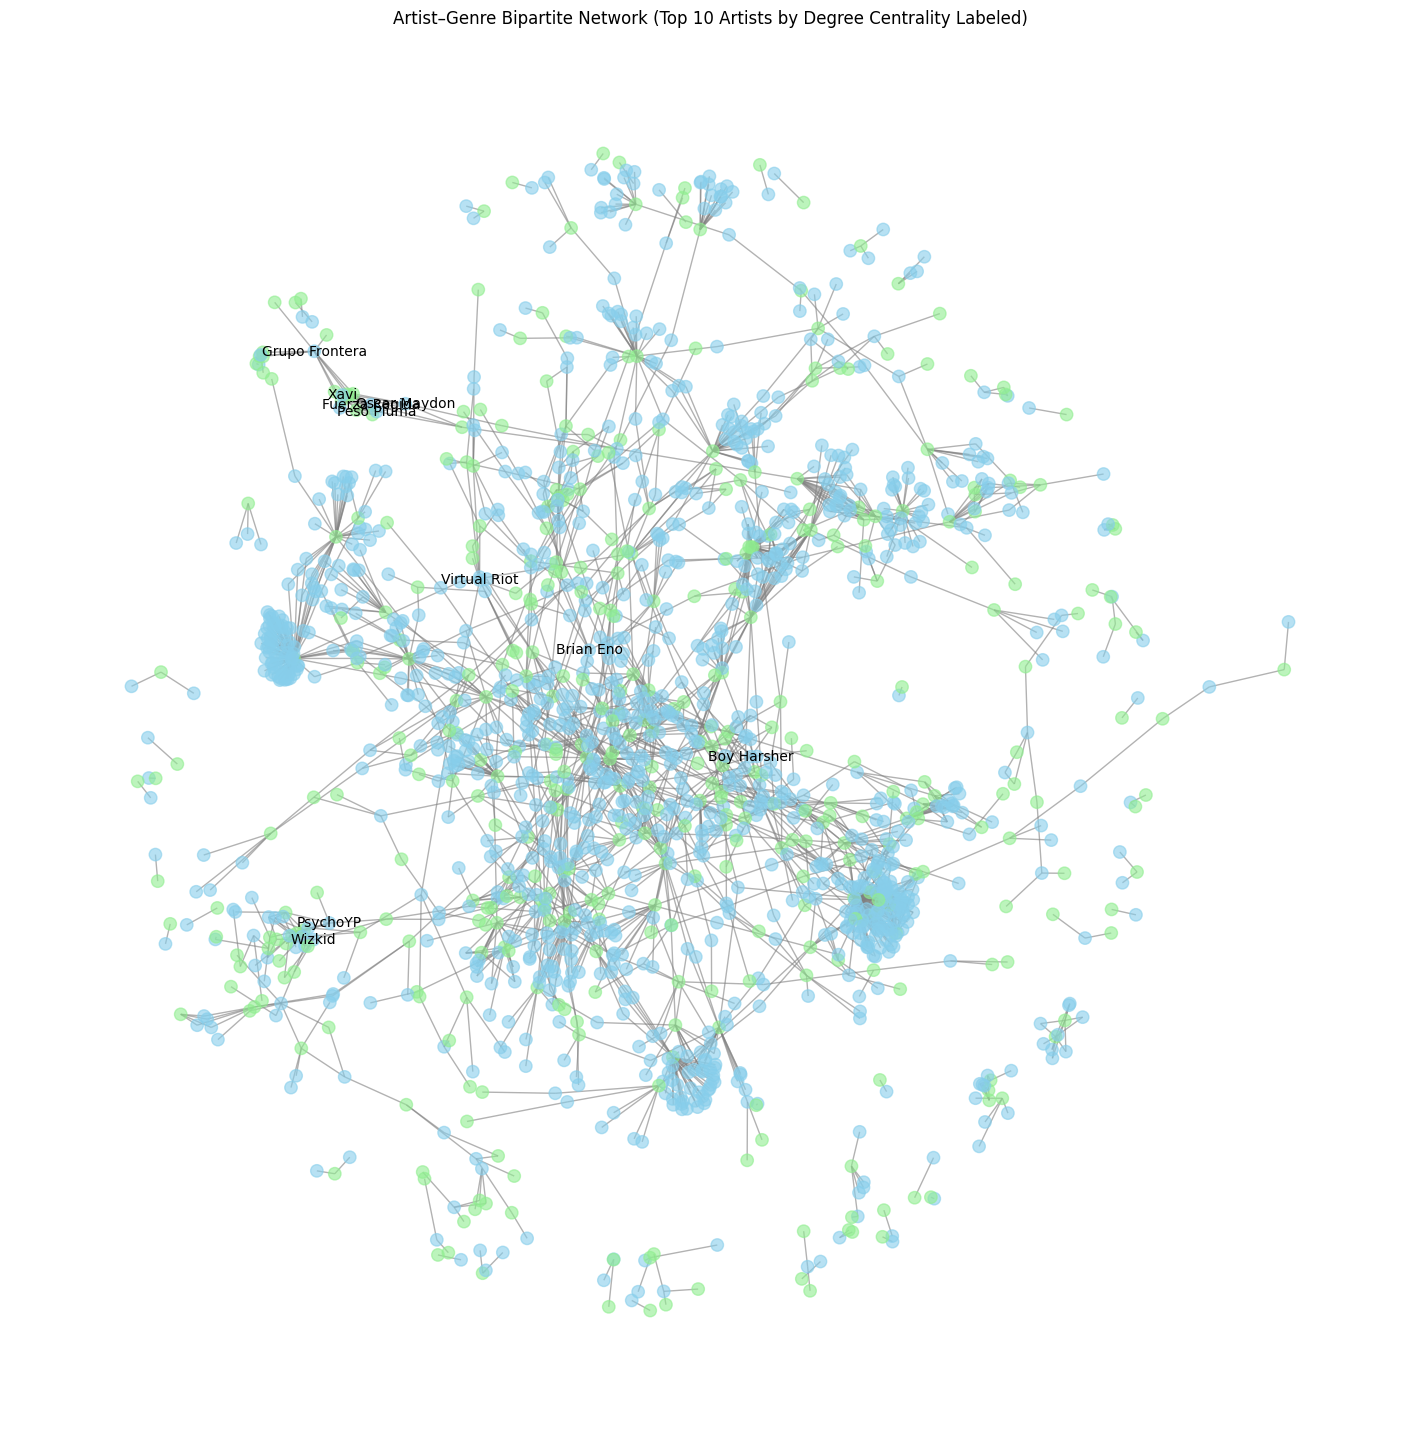

In [25]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.35, seed=42)

artist_nodes = set(df["artist_name"])
node_colors = ["skyblue" if n in artist_nodes else "lightgreen" for n in G.nodes()]

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

labels = {artist: artist for artist, score in top_degree}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

plt.title("Artist–Genre Bipartite Network (Top 10 Artists by Degree Centrality Labeled)")
plt.show()


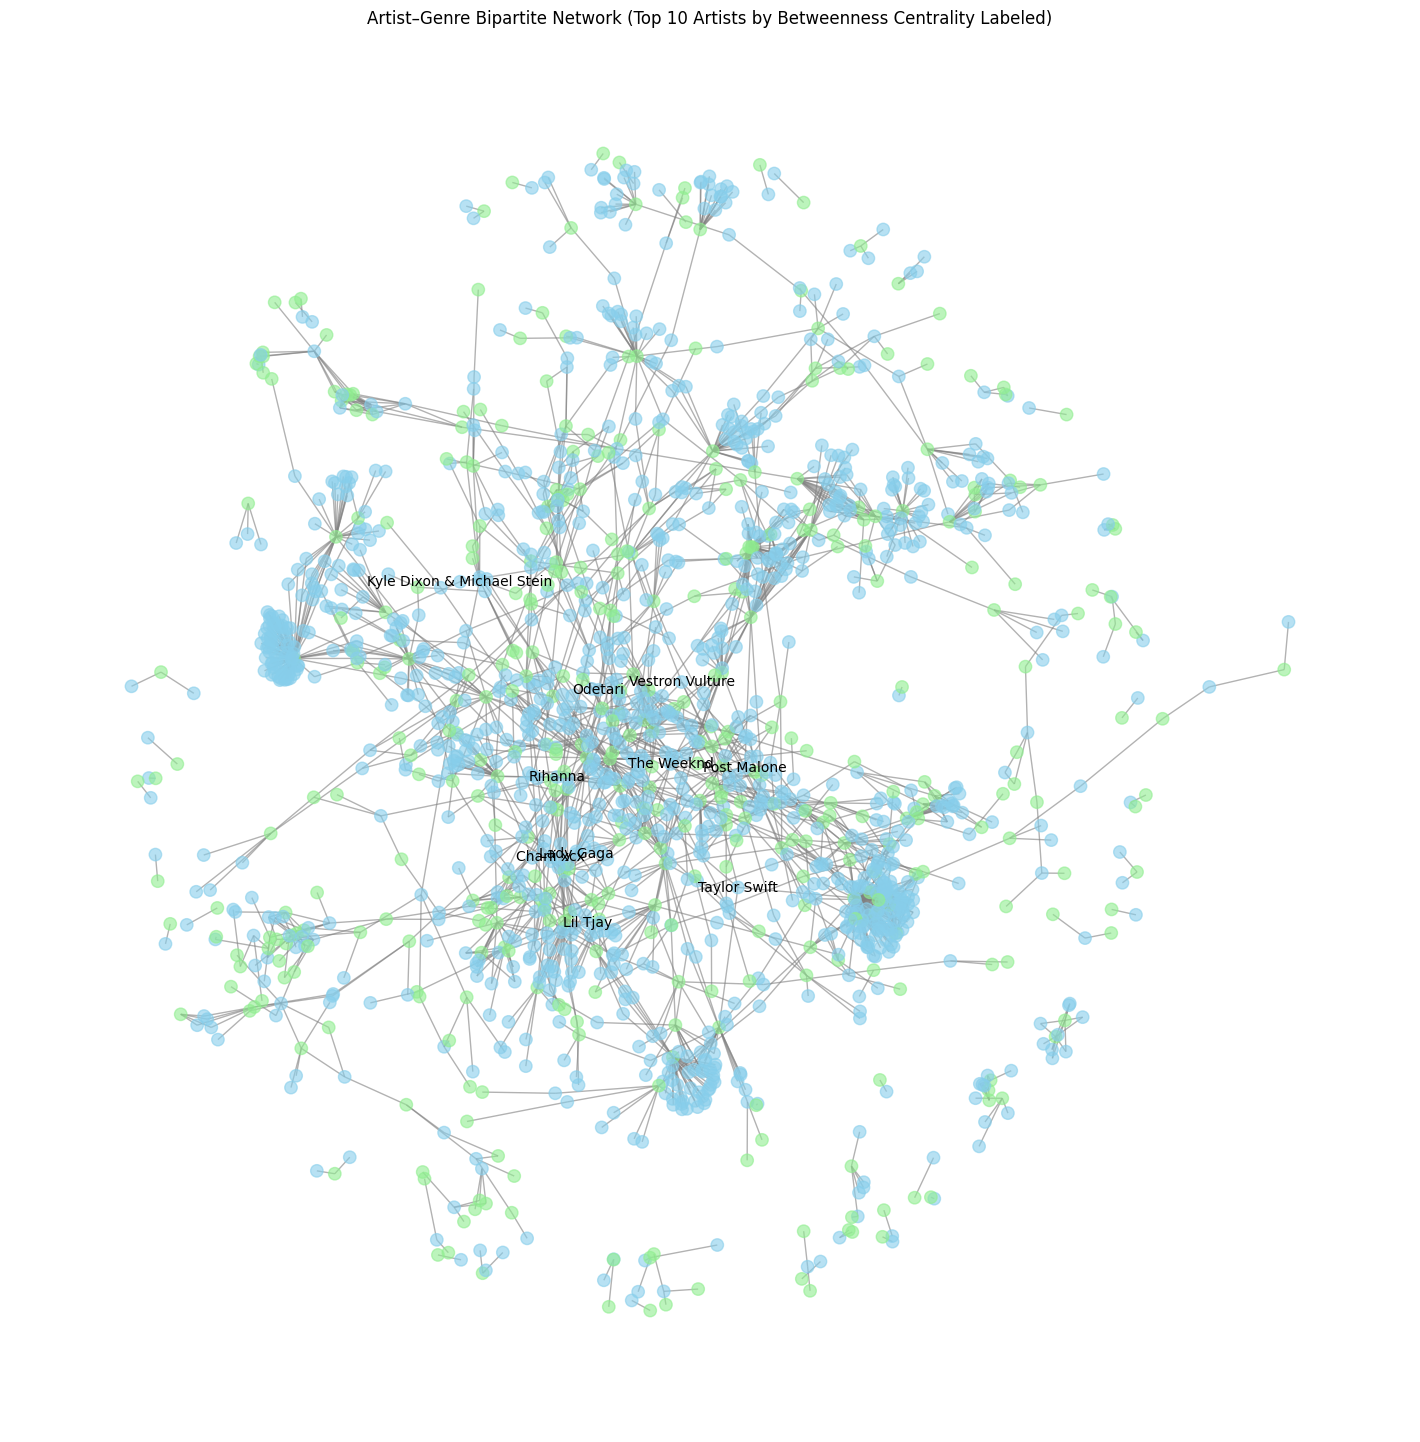

In [26]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.35, seed=42)

artist_nodes = set(df["artist_name"])
node_colors = ["skyblue" if n in artist_nodes else "lightgreen" for n in G.nodes()]

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

labels = {artist: artist for artist, score in top_bridge}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

plt.title("Artist–Genre Bipartite Network (Top 10 Artists by Betweenness Centrality Labeled)")
plt.show()


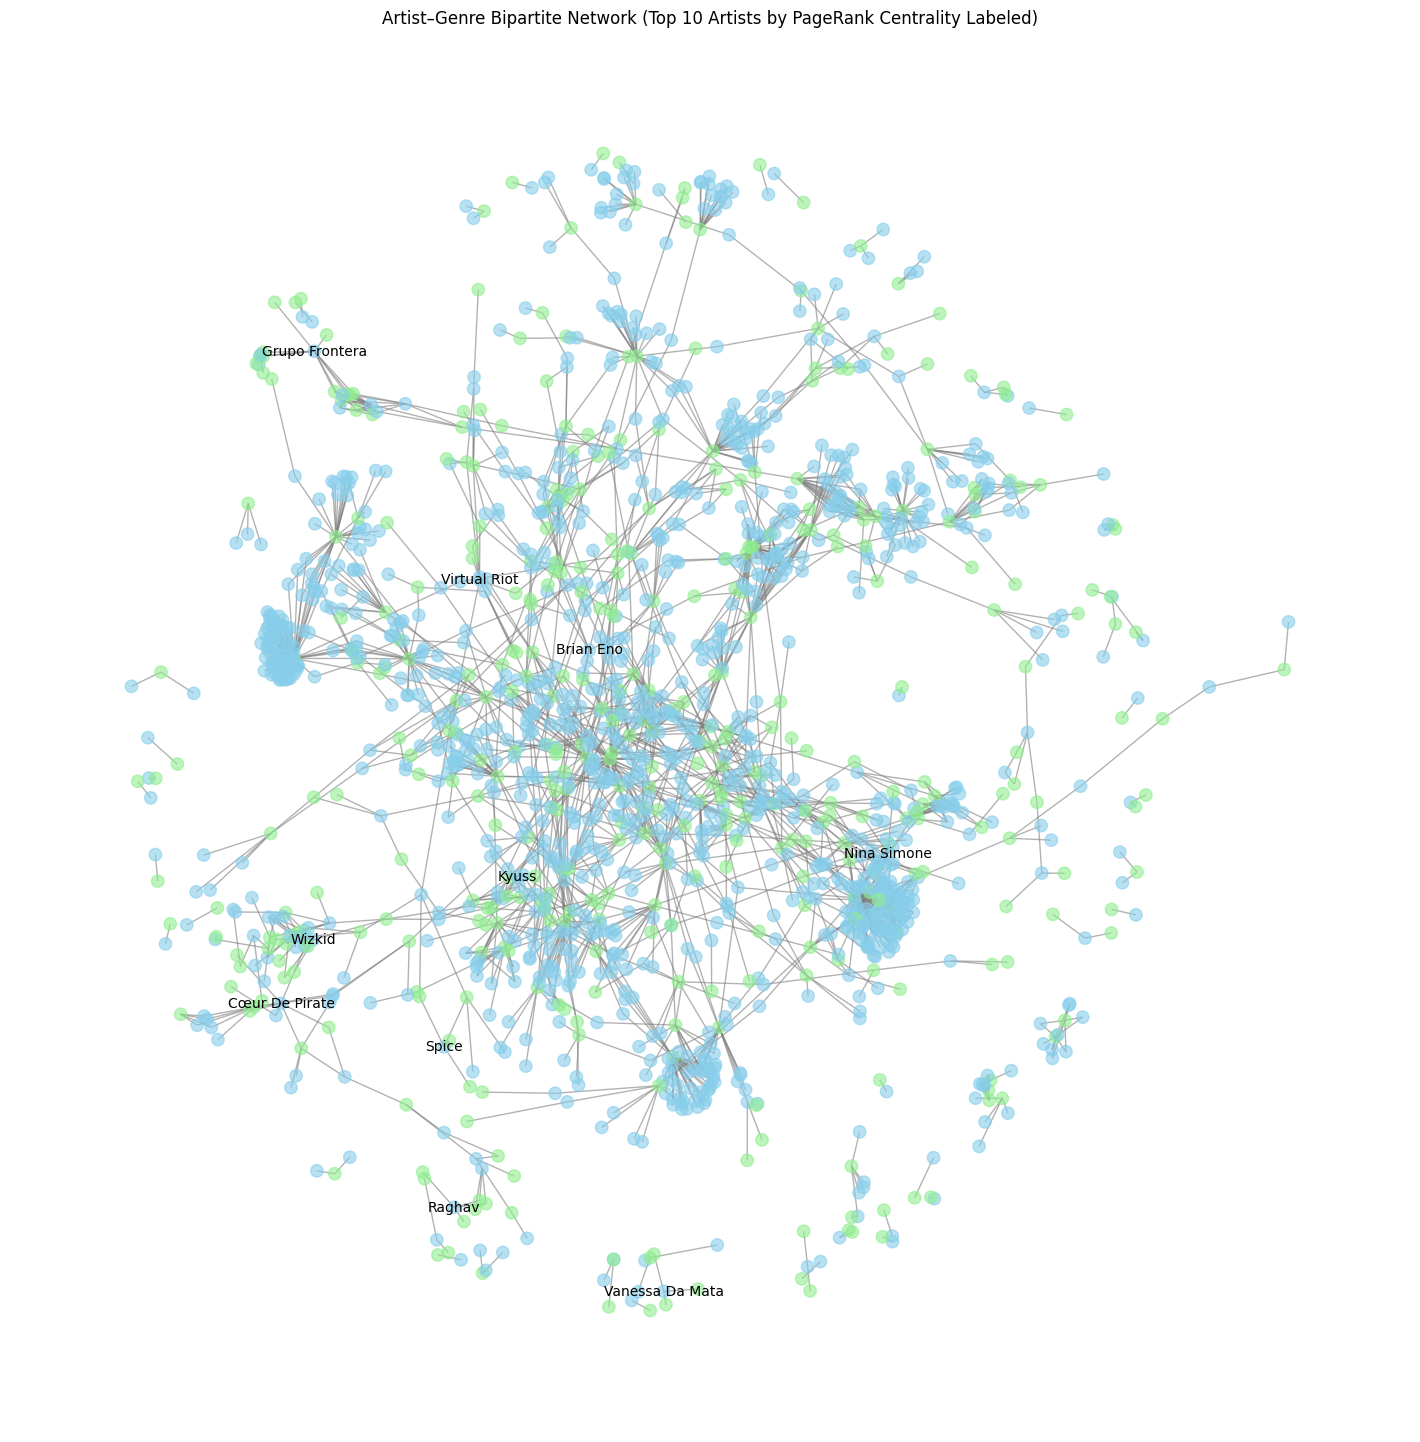

In [27]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.35, seed=42)

artist_nodes = set(df["artist_name"])
node_colors = ["skyblue" if n in artist_nodes else "lightgreen" for n in G.nodes()]

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

labels = {artist: artist for artist, score in top_pr}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

plt.title("Artist–Genre Bipartite Network (Top 10 Artists by PageRank Centrality Labeled)")
plt.show()
